In [ ]:
from google.colab import files
uploaded = files.upload()

Saving drug.csv to drug.csv
Saving iris.csv to iris.csv
Saving petrol_consumption.csv to petrol_consumption.csv


In [ ]:
# iris.csv & drug.csv

In [ ]:
# with libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

iris = pd.read_csv("iris.csv")

X = iris.iloc[:, :-1]
y = iris.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("IRIS DATASET")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

drug = pd.read_csv("drug.csv")

le = LabelEncoder()

for column in drug.columns:
    if drug[column].dtype == 'object':
        drug[column] = le.fit_transform(drug[column])

X = drug.iloc[:, :-1]
y = drug.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nDRUG DATASET")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

IRIS DATASET
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

DRUG DATASET
Accuracy: 1.0
Confusion Matrix:
 [[ 6  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 15]]


In [ ]:
# without libraries

import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split


def entropy(y):
    counts = np.bincount(y)
    probs = counts / len(y)
    return -np.sum([p * np.log2(p) for p in probs if p > 0])


def information_gain(X_column, y, threshold):
    parent_entropy = entropy(y)

    left = y[X_column < threshold]
    right = y[X_column >= threshold]

    if len(left) == 0 or len(right) == 0:
        return 0

    n = len(y)
    n_l = len(left)
    n_r = len(right)

    child_entropy = (n_l/n)*entropy(left) + (n_r/n)*entropy(right)

    ig = parent_entropy - child_entropy
    return ig


class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


class SimpleDecisionTree:

    def fit(self, X, y):
        self.root = self.build_tree(X, y)

    def build_tree(self, X, y):
        if len(set(y)) == 1:
            return Node(value=y[0])

        best_feature = None
        best_threshold = None
        best_gain = -1

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])

            for t in thresholds:
                gain = information_gain(X[:, feature], y, t)

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = t

        if best_gain == 0:
            return Node(value=Counter(y).most_common(1)[0][0])

        left_idx = X[:, best_feature] < best_threshold
        right_idx = X[:, best_feature] >= best_threshold

        left = self.build_tree(X[left_idx], y[left_idx])
        right = self.build_tree(X[right_idx], y[right_idx])

        return Node(best_feature, best_threshold, left, right)

    def predict_row(self, x, node):
        if node.value is not None:
            return node.value

        if x[node.feature] < node.threshold:
            return self.predict_row(x, node.left)
        else:
            return self.predict_row(x, node.right)

    def predict(self, X):
        return np.array([self.predict_row(x, self.root) for x in X])


data = pd.read_csv("iris.csv")

for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = data[column].astype('category').cat.codes

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

tree = SimpleDecisionTree()
tree.fit(X_train, y_train)

pred = tree.predict(X_test)

accuracy = np.sum(pred == y_test) / len(y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [ ]:
# petrol_consumption.csv

In [ ]:
# with libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


dataset = pd.read_csv("petrol_consumption.csv")

X = dataset.iloc[:, 0:4].values
y = dataset.iloc[:, 4].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

regressor = DecisionTreeRegressor(random_state=0)

regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

accuracy = (1 - (np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)))) * 100
print("Accuracy:", accuracy)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))

Accuracy: 90.75354932653804
Mean Absolute Error: 50.8
Mean Squared Error: 4535.4
Root Mean Squared Error: 67.34537846058926


In [ ]:
# without libraries

import pandas as pd
import numpy as np
from math import sqrt


data = pd.read_csv("petrol_consumption.csv")

X = data.iloc[:, 0:4].values
y = data.iloc[:, 4].values

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]


def variance(y):
    return np.var(y)


def best_split(X, y):
    best_feature = None
    best_threshold = None
    best_error = float('inf')

    for feature in range(X.shape[1]):
        thresholds = np.unique(X[:, feature])

        for t in thresholds:
            left = y[X[:, feature] < t]
            right = y[X[:, feature] >= t]

            if len(left) == 0 or len(right) == 0:
                continue

            error = variance(left)*len(left) + variance(right)*len(right)

            if error < best_error:
                best_error = error
                best_feature = feature
                best_threshold = t

    return best_feature, best_threshold


class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


def build_tree(X, y, depth=0, max_depth=3):

    if depth >= max_depth or len(set(y)) == 1:
        return Node(value=np.mean(y))

    feature, threshold = best_split(X, y)

    if feature is None:
        return Node(value=np.mean(y))

    left_idx = X[:, feature] < threshold
    right_idx = X[:, feature] >= threshold

    left = build_tree(X[left_idx], y[left_idx], depth+1, max_depth)
    right = build_tree(X[right_idx], y[right_idx], depth+1, max_depth)

    return Node(feature, threshold, left, right)


def predict_one(x, node):
    if node.value is not None:
        return node.value

    if x[node.feature] < node.threshold:
        return predict_one(x, node.left)
    else:
        return predict_one(x, node.right)


def predict(X, tree):
    return np.array([predict_one(x, tree) for x in X])


tree = build_tree(X_train, y_train)

y_pred = predict(X_test, tree)


def MAE(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def MSE(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def RMSE(y_true, y_pred):
    return sqrt(MSE(y_true, y_pred))

accuracy = (1 - (np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)))) * 100
print("Accuracy:", accuracy)
print("Mean Absolute Error:", MAE(y_test, y_pred))
print("Mean Squared Error:", MSE(y_test, y_pred))
print("Root Mean Squared Error:", RMSE(y_test, y_pred))

Accuracy: 81.78249776479053
Mean Absolute Error: 119.34285714285716
Mean Squared Error: 27365.47653061225
Root Mean Squared Error: 165.42513875046998


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text

data = pd.read_csv("petrol_consumption.csv")

X = data.iloc[:, 0:4]
y = data.iloc[:, 4]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

tree_rules = export_text(model, feature_names=list(X.columns))
print(tree_rules)

|--- Population_Driver_licence(%) <= 0.67
|   |--- Average_income <= 4731.50
|   |   |--- Petrol_tax <= 7.75
|   |   |   |--- Paved_Highways <= 5652.50
|   |   |   |   |--- Average_income <= 4007.00
|   |   |   |   |   |--- Petrol_tax <= 7.25
|   |   |   |   |   |   |--- Population_Driver_licence(%) <= 0.55
|   |   |   |   |   |   |   |--- value: [714.00]
|   |   |   |   |   |   |--- Population_Driver_licence(%) >  0.55
|   |   |   |   |   |   |   |--- value: [699.00]
|   |   |   |   |   |--- Petrol_tax >  7.25
|   |   |   |   |   |   |--- value: [628.00]
|   |   |   |   |--- Average_income >  4007.00
|   |   |   |   |   |--- Paved_Highways <= 3859.00
|   |   |   |   |   |   |--- value: [632.00]
|   |   |   |   |   |--- Paved_Highways >  3859.00
|   |   |   |   |   |   |--- value: [610.00]
|   |   |   |--- Paved_Highways >  5652.50
|   |   |   |   |--- Population_Driver_licence(%) <= 0.56
|   |   |   |   |   |--- Average_income <= 3923.50
|   |   |   |   |   |   |--- Population_Driver_

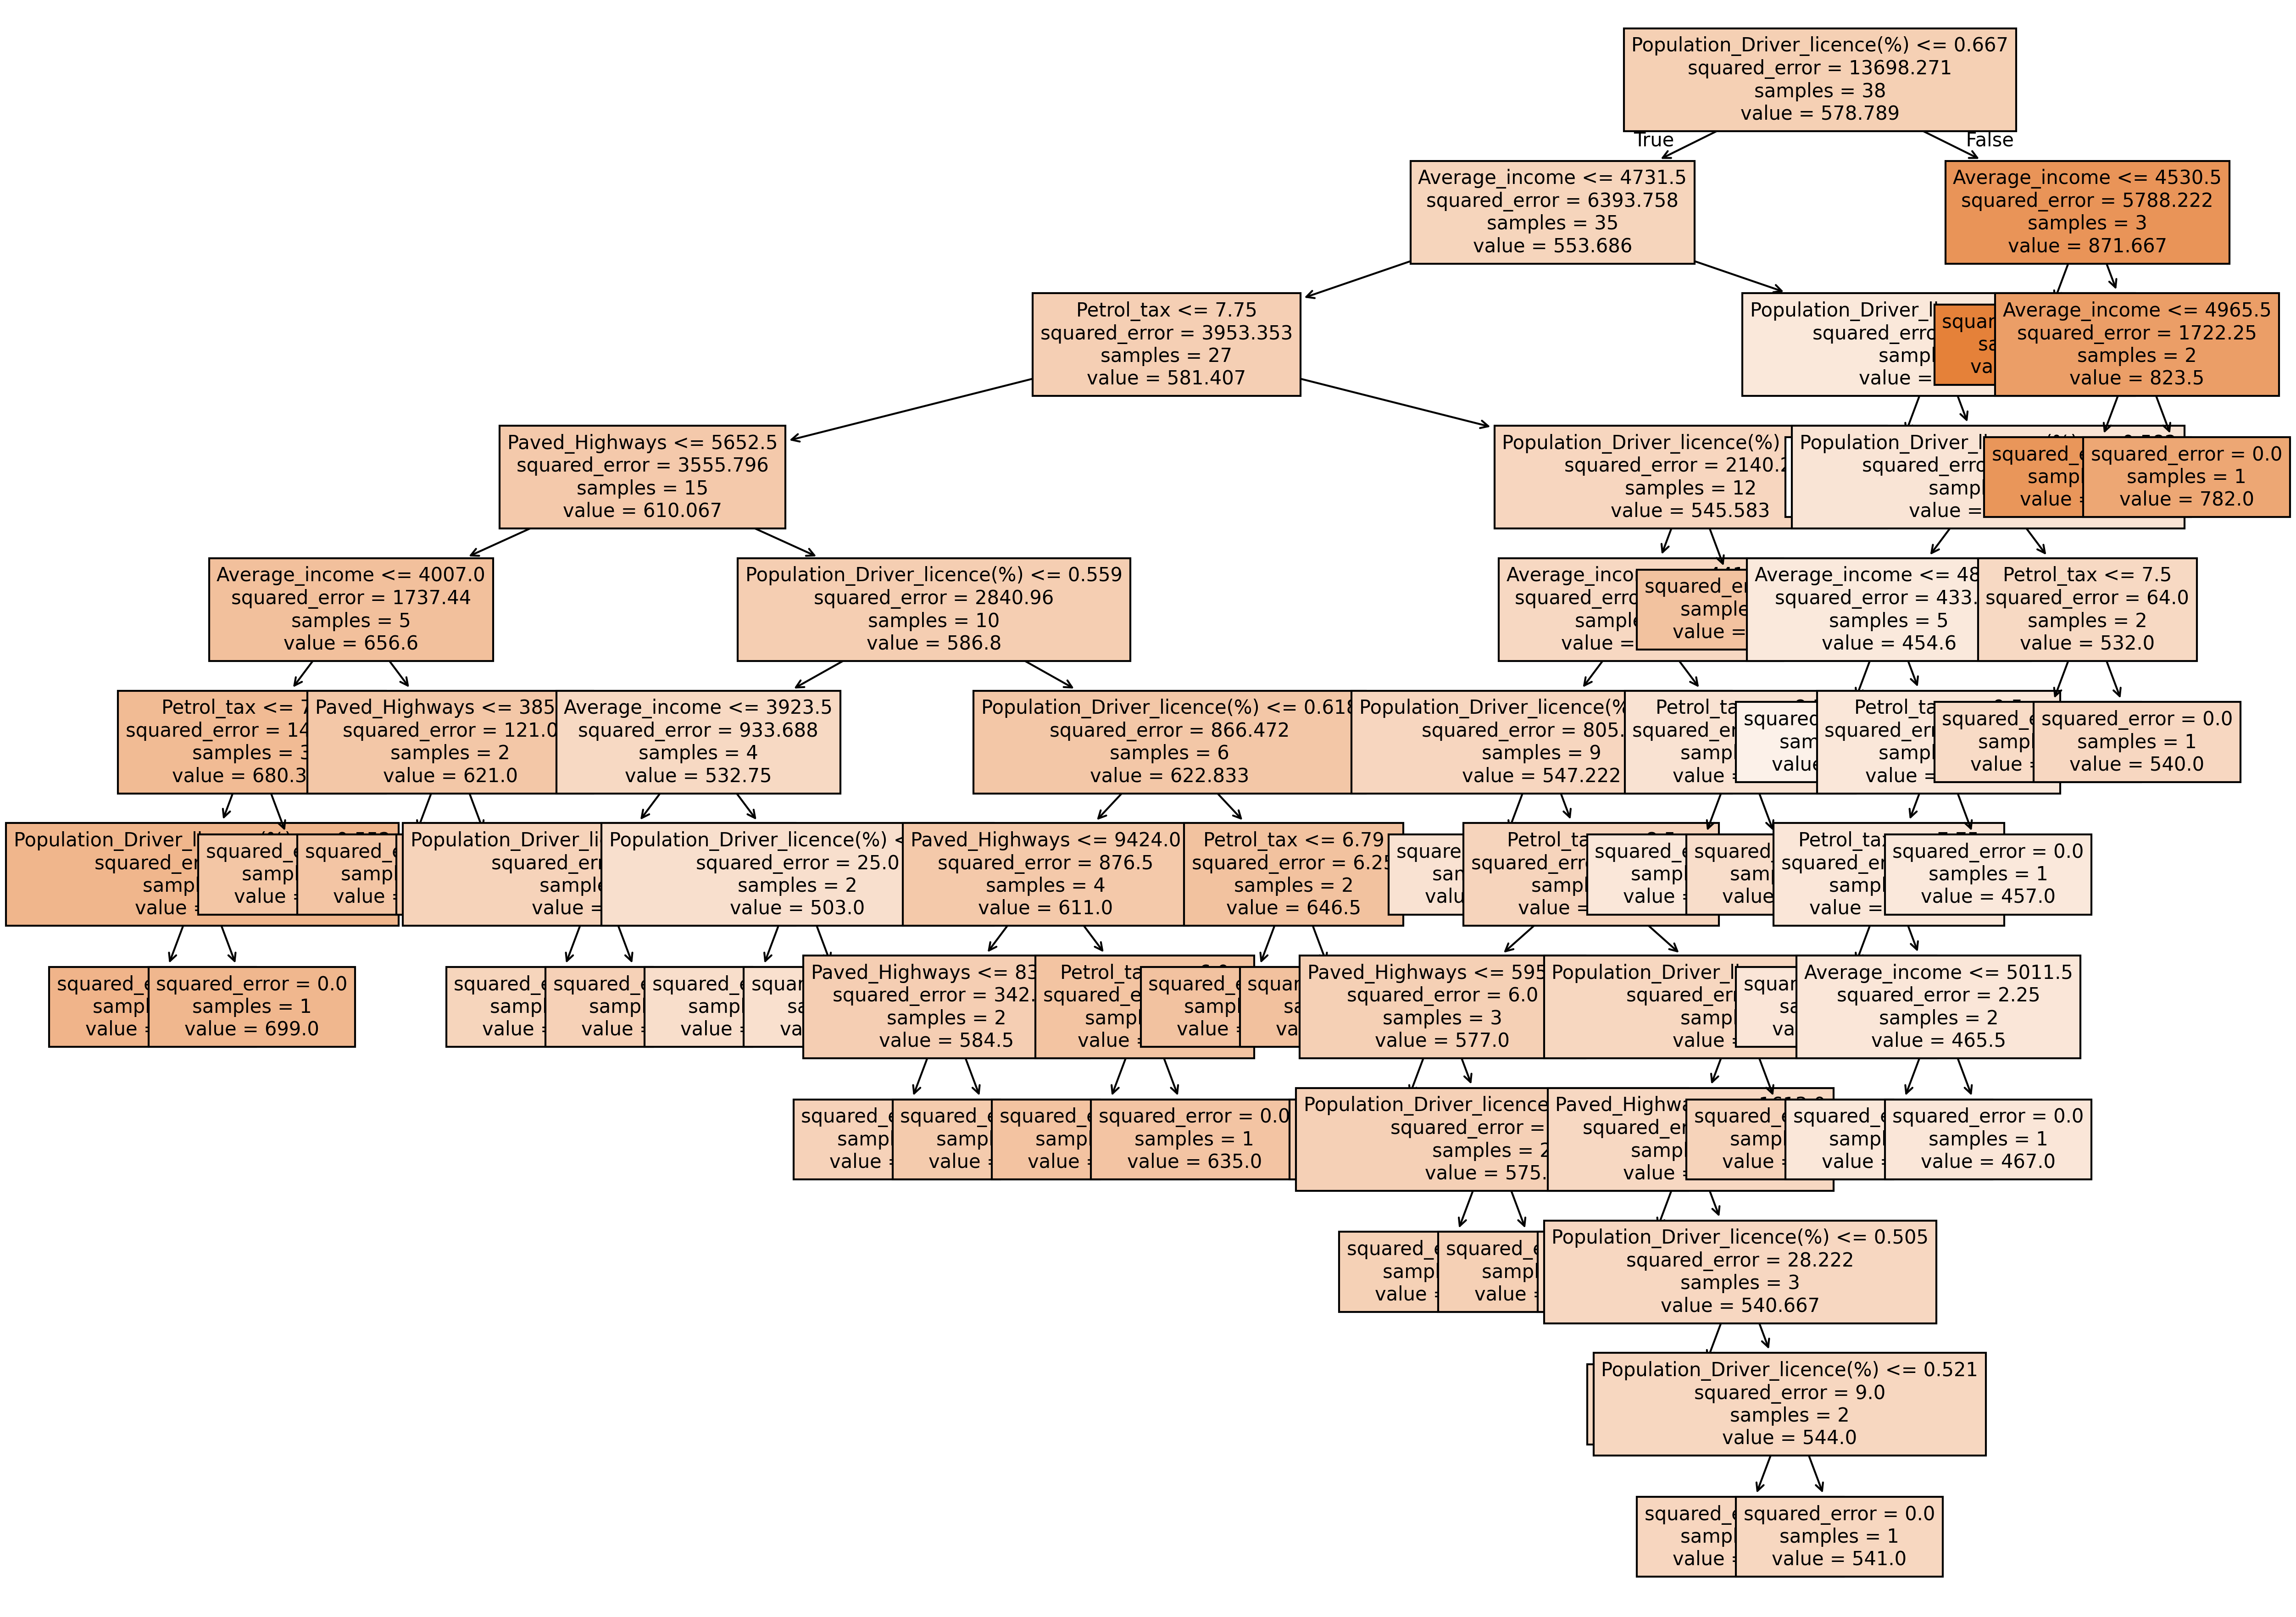

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 15), dpi=300)

plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    fontsize=10
)

plt.show()